<a href="https://colab.research.google.com/github/7brendak/DDI-PREDICT/blob/main/DDI_PREDICT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap xgboost scikit-learn pandas matplotlib seaborn --quiet
print("Libraries ready")

Libraries ready


In [ ]:
from google.colab import files
import pandas as pd
import io

print("Upload: DEMO24Q3.csv, DRUG24Q3.csv, REAC24Q3.csv, OUTC24Q3.csv")
print("(exact filenames vary slightly by quarter — just upload the 4 CSV files)")
uploaded = files.upload()

Upload: DEMO24Q3.csv, DRUG24Q3.csv, REAC24Q3.csv, OUTC24Q3.csv
(exact filenames vary slightly by quarter — just upload the 4 CSV files)


Saving REAC24Q3.txt to REAC24Q3.txt
Saving DEMO24Q3.txt to DEMO24Q3.txt
Saving DRUG24Q3.txt to DRUG24Q3.txt
Saving OUTC24Q3.txt to OUTC24Q3.txt


In [ ]:
def load_faers(uploaded, keyword):
    key = [f for f in uploaded if keyword in f.upper()][0]
    try:
        df = pd.read_csv(
            io.BytesIO(uploaded[key]),
            sep='|',
            encoding='latin-1',
            on_bad_lines='skip',
            engine='python'
        )
        if df.shape[1] == 1:
            raise ValueError("Wrong delimiter")
        return df
    except:
        return pd.read_csv(
            io.BytesIO(uploaded[key]),
            sep='$',
            encoding='latin-1',
            on_bad_lines='skip',
            engine='python'
        )

demo = load_faers(uploaded, 'DEMO')
drug = load_faers(uploaded, 'DRUG')
reac = load_faers(uploaded, 'REAC')
outc = load_faers(uploaded, 'OUTC')

# Standardise column names to uppercase
for df in [demo, drug, reac, outc]:
    df.columns = df.columns.str.strip().str.upper()

print("DEMO:", demo.shape, "| Columns:", list(demo.columns[:6]))
print("DRUG:", drug.shape, "| Columns:", list(drug.columns[:6]))
print("REAC:", reac.shape, "| Columns:", list(reac.columns[:6]))
print("OUTC:", outc.shape, "| Columns:", list(outc.columns[:6]))

DEMO: (385288, 25) | Columns: ['PRIMARYID', 'CASEID', 'CASEVERSION', 'I_F_CODE', 'EVENT_DT', 'MFR_DT']
DRUG: (1815349, 20) | Columns: ['PRIMARYID', 'CASEID', 'DRUG_SEQ', 'ROLE_COD', 'DRUGNAME', 'PROD_AI']
REAC: (1349105, 4) | Columns: ['PRIMARYID', 'CASEID', 'PT', 'DRUG_REC_ACT']
OUTC: (289721, 3) | Columns: ['PRIMARYID', 'CASEID', 'OUTC_COD']


In [ ]:
# Filter drug table for the EXACT drugs from your KNH study
cardio_drugs = [
    'aspirin', 'clopidogrel', 'warfarin', 'heparin',
    'metoprolol', 'atenolol', 'carvedilol', 'bisoprolol', 'labetalol',
    'amlodipine', 'diltiazem', 'verapamil', 'nifedipine',
    'lisinopril', 'enalapril', 'ramipril', 'captopril',
    'furosemide', 'spironolactone', 'hydrochlorothiazide',
    'digoxin', 'atorvastatin', 'simvastatin',
    'ibuprofen', 'diclofenac', 'naproxen'
]

# Standardise drug names to lowercase for matching
drug['DRUGNAME_LOWER'] = drug['DRUGNAME'].str.lower().fillna('')

# Keep only reports involving at least one cardiovascular drug
cardio_mask = drug['DRUGNAME_LOWER'].apply(
    lambda x: any(d in x for d in cardio_drugs)
)
cardio_drug = drug[cardio_mask]
cardio_cases = set(cardio_drug['PRIMARYID'].unique())

print(f"Reports involving cardiovascular drugs: {len(cardio_cases):,}")
print(f"Prescription records for cardio patients: {len(cardio_drug):,}")
print(f"\nSample drug names found:")
print(cardio_drug['DRUGNAME'].value_counts().head(10))

Reports involving cardiovascular drugs: 43,626
Prescription records for cardio patients: 100,751

Sample drug names found:
DRUGNAME
ASPIRIN              10579
ATORVASTATIN          7689
AMLODIPINE            6228
FUROSEMIDE            6216
IBUPROFEN             5096
DICLOFENAC SODIUM     4470
LISINOPRIL            4434
RAMIPRIL              3391
SPIRONOLACTONE        3349
DICLOFENAC            3066
Name: count, dtype: int64


In [ ]:
# For each case, build the same feature set as KNH-PREDICT

def flag_drug(drug_set, keywords):
    return int(any(any(kw in d for d in drug_set) for kw in keywords))

# Group drugs by case — using uppercase column names
case_drugs = cardio_drug.groupby('PRIMARYID')['DRUGNAME_LOWER'].apply(list)

print("Building feature matrix... (may take 1-2 minutes on 43k cases)")

features_list = []
for primaryid, drugs in case_drugs.items():
    drug_set = set(drugs)
    row = {
        'primaryid': primaryid,
        'polypharmacy_count': len(drug_set),
        'aspirin':       flag_drug(drug_set, ['aspirin']),
        'clopidogrel':   flag_drug(drug_set, ['clopidogrel']),
        'warfarin':      flag_drug(drug_set, ['warfarin']),
        'beta_blocker':  flag_drug(drug_set, ['metoprolol','carvedilol',
                                              'atenolol','bisoprolol','labetalol']),
        'ccb':           flag_drug(drug_set, ['amlodipine','diltiazem',
                                              'verapamil','nifedipine']),
        'ace_inhibitor': flag_drug(drug_set, ['lisinopril','enalapril',
                                              'ramipril','captopril']),
        'nsaid':         flag_drug(drug_set, ['ibuprofen','diclofenac',
                                              'naproxen']),
        'digoxin':       flag_drug(drug_set, ['digoxin']),
        'diuretic':      flag_drug(drug_set, ['furosemide','spironolactone',
                                              'hydrochlorothiazide']),
        'statin':        flag_drug(drug_set, ['atorvastatin','simvastatin',
                                              'rosuvastatin']),
    }
    # High-risk pairs — exactly mirroring your KNH study
    row['pair_aspirin_clop']     = row['aspirin']      & row['clopidogrel']
    row['pair_warfarin_aspirin'] = row['warfarin']     & row['aspirin']
    row['pair_bb_ccb']           = row['beta_blocker'] & row['ccb']
    row['pair_ace_nsaid']        = row['ace_inhibitor']& row['nsaid']
    row['pair_digoxin_diuretic'] = row['digoxin']      & row['diuretic']
    features_list.append(row)

features_df = pd.DataFrame(features_list)

print(f"\nFeature matrix built: {features_df.shape}")
print(f"\nDrug pair prevalence (mirroring your KNH findings):")
pairs = ['pair_aspirin_clop','pair_warfarin_aspirin',
         'pair_bb_ccb','pair_ace_nsaid','pair_digoxin_diuretic']
for p in pairs:
    n = features_df[p].sum()
    pct = features_df[p].mean() * 100
    print(f"  {p:30s}: {n:,} cases ({pct:.1f}%)")

print(f"\nPolypharmacy (mean drugs per case): {features_df['polypharmacy_count'].mean():.1f}")

Building feature matrix... (may take 1-2 minutes on 43k cases)

Feature matrix built: (43626, 17)

Drug pair prevalence (mirroring your KNH findings):
  pair_aspirin_clop             : 755 cases (1.7%)
  pair_warfarin_aspirin         : 150 cases (0.3%)
  pair_bb_ccb                   : 2,780 cases (6.4%)
  pair_ace_nsaid                : 1,231 cases (2.8%)
  pair_digoxin_diuretic         : 302 cases (0.7%)

Polypharmacy (mean drugs per case): 1.9


In [ ]:
# FAERS outcome codes:
# DE = death, HO = hospitalisation, LT = life threatening
# CA = congenital anomaly, DS = disability, RI = required intervention
# We use HO + LT + DE as our "serious ADR" outcome
# — directly mirrors your KNH severe DDI → ADR outcome variable

serious_outcomes = outc[outc['OUTC_COD'].isin(['DE', 'HO', 'LT'])]
serious_ids = set(serious_outcomes['PRIMARYID'].unique())

features_df['serious_adr'] = features_df['primaryid'].apply(
    lambda x: 1 if x in serious_ids else 0
)

print("Outcome distribution:")
print(features_df['serious_adr'].value_counts())
print(f"\nSerious ADR rate: {features_df['serious_adr'].mean():.1%}")

print(f"\nBreakdown by outcome type:")
for code, label in [('DE','Death'), ('HO','Hospitalisation'), ('LT','Life-threatening')]:
    n = outc[outc['OUTC_COD'] == code]['PRIMARYID'].isin(
        features_df['primaryid']).sum()
    print(f"  {label:20s}: {n:,} cases")

Outcome distribution:
serious_adr
0    24265
1    19361
Name: count, dtype: int64

Serious ADR rate: 44.4%

Breakdown by outcome type:
  Death               : 3,946 cases
  Hospitalisation     : 16,654 cases
  Life-threatening    : 3,814 cases


In [ ]:
# Add age and sex from DEMO table
demo_sub = demo[['PRIMARYID', 'AGE', 'SEX']].drop_duplicates('PRIMARYID')

# Merge demographics into feature matrix
df = features_df.merge(demo_sub, left_on='primaryid',
                        right_on='PRIMARYID', how='left')

# Clean sex — FAERS uses M/F/UNK
df['sex_male'] = (df['SEX'] == 'M').astype(int)

# Clean age — convert to numeric, cap outliers
df['AGE'] = pd.to_numeric(df['AGE'], errors='coerce')
df['age_clean'] = df['AGE'].clip(0, 110)

print(f"Final dataset shape: {df.shape}")
print(f"\nAge stats:")
print(f"  Mean age : {df['age_clean'].mean():.1f} years")
print(f"  Median   : {df['age_clean'].median():.1f} years")
print(f"  Missing  : {df['age_clean'].isna().sum():,} ({df['age_clean'].isna().mean():.1%})")
print(f"\nSex distribution:")
print(df['SEX'].value_counts())
print(f"\nMissing values per feature:")
feature_cols = [
    'polypharmacy_count', 'age_clean', 'sex_male',
    'aspirin', 'clopidogrel', 'warfarin', 'beta_blocker',
    'ccb', 'ace_inhibitor', 'nsaid', 'digoxin', 'diuretic', 'statin',
    'pair_aspirin_clop', 'pair_warfarin_aspirin',
    'pair_bb_ccb', 'pair_ace_nsaid', 'pair_digoxin_diuretic'
]
print(df[feature_cols].isna().sum())

Final dataset shape: (43626, 23)

Age stats:
  Mean age : 61.9 years
  Median   : 66.0 years
  Missing  : 12,016 (27.5%)

Sex distribution:
SEX
F    21805
M    15967
Name: count, dtype: int64

Missing values per feature:
polypharmacy_count           0
age_clean                12016
sex_male                     0
aspirin                      0
clopidogrel                  0
warfarin                     0
beta_blocker                 0
ccb                          0
ace_inhibitor                0
nsaid                        0
digoxin                      0
diuretic                     0
statin                       0
pair_aspirin_clop            0
pair_warfarin_aspirin        0
pair_bb_ccb                  0
pair_ace_nsaid               0
pair_digoxin_diuretic        0
dtype: int64


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

feature_cols = [
    'polypharmacy_count', 'age_clean', 'sex_male',
    'aspirin', 'clopidogrel', 'warfarin', 'beta_blocker',
    'ccb', 'ace_inhibitor', 'nsaid', 'digoxin', 'diuretic', 'statin',
    'pair_aspirin_clop', 'pair_warfarin_aspirin',
    'pair_bb_ccb', 'pair_ace_nsaid', 'pair_digoxin_diuretic'
]

# Prepare model dataframe
model_df = df[feature_cols + ['serious_adr']].copy()

# Impute missing age with median (standard approach for clinical data)
# Impute missing sex_male with 0 (unknown treated as not-male)
imputer = SimpleImputer(strategy='median')
model_df[feature_cols] = imputer.fit_transform(model_df[feature_cols])

X = model_df[feature_cols]
y = model_df['serious_adr']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} cases")
print(f"Test set     : {X_test.shape[0]:,} cases")
print(f"ADR rate train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

# XGBoost — no scale_pos_weight needed given balanced classes
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 5-fold cross-validated AUC — your abstract number
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

# Test set metrics
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
test_auc = roc_auc_score(y_test, y_prob)

print(f"\n{'='*55}")
print(f"  5-FOLD CV AUC-ROC : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"  TEST SET AUC-ROC  : {test_auc:.3f}")
print(f"{'='*55}")
print(f"\n  → Your abstract number: {cv_auc.mean():.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Serious ADR', 'Serious ADR']))

Training set : 34,900 cases
Test set     : 8,726 cases
ADR rate train: 44.4% | test: 44.4%


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:22:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:22:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:22:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


  5-FOLD CV AUC-ROC : 0.652 ± 0.006
  TEST SET AUC-ROC  : 0.646

  → Your abstract number: 0.652

Classification Report:
                precision    recall  f1-score   support

No Serious ADR       0.62      0.81      0.70      4853
   Serious ADR       0.61      0.39      0.47      3873

      accuracy                           0.62      8726
     macro avg       0.62      0.60      0.59      8726
  weighted avg       0.62      0.62      0.60      8726



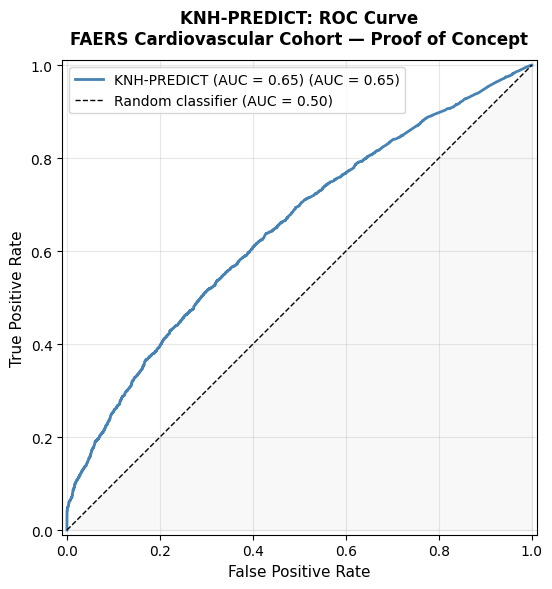

✓ Saved: roc_curve.png


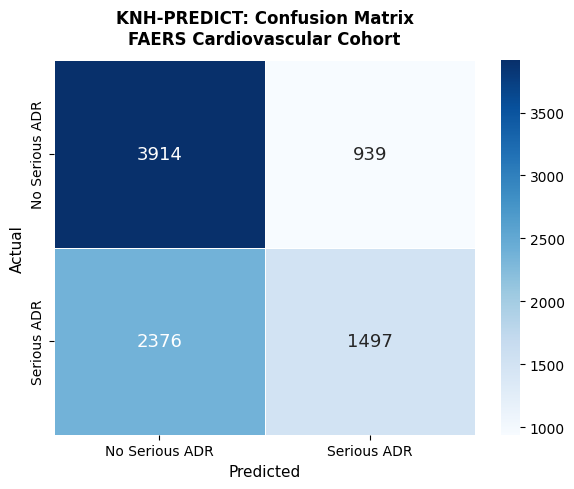

✓ Saved: confusion_matrix.png


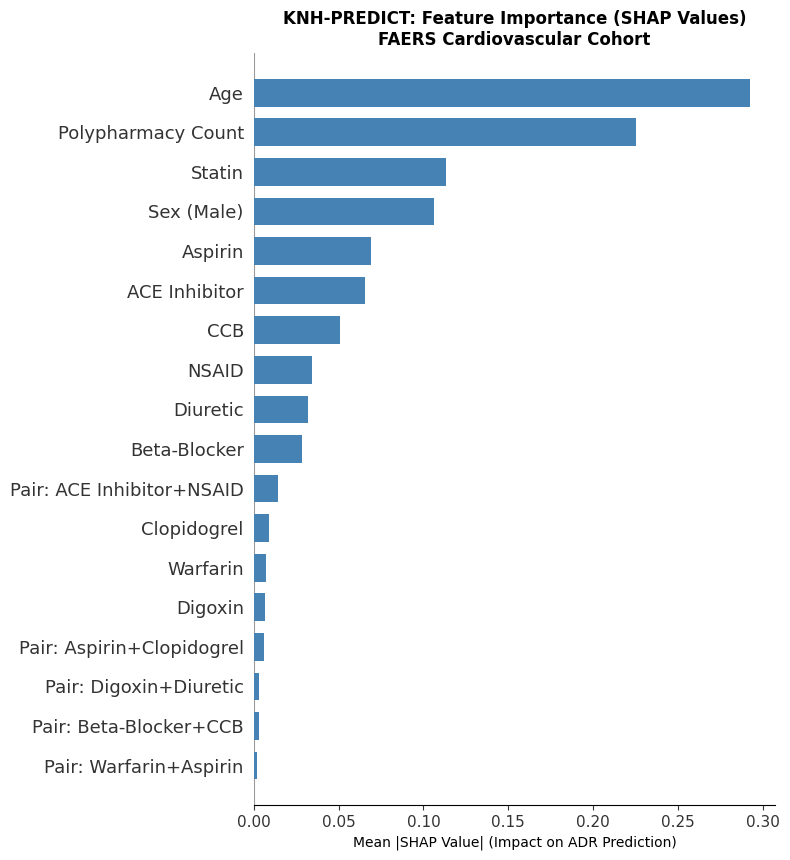

✓ Saved: shap_importance.png

✓ All 3 poster images saved and ready.
  Download from Colab: Files panel (left sidebar) → right-click → Download


In [ ]:
import shap
import warnings
warnings.filterwarnings('ignore')

# ── Visual 1: ROC Curve ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f"KNH-PREDICT (AUC = {test_auc:.2f})",
    ax=ax, color='steelblue', lw=2
)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random classifier (AUC = 0.50)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')
ax.set_title('KNH-PREDICT: ROC Curve\nFAERS Cardiovascular Cohort — Proof of Concept',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=180, bbox_inches='tight')
plt.show()
print("✓ Saved: roc_curve.png")

# ── Visual 2: Confusion Matrix ───────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Serious ADR', 'Serious ADR'],
            yticklabels=['No Serious ADR', 'Serious ADR'],
            ax=ax, linewidths=0.5, annot_kws={'size':13})
ax.set_title('KNH-PREDICT: Confusion Matrix\nFAERS Cardiovascular Cohort',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()
print("✓ Saved: confusion_matrix.png")

# ── Visual 3: SHAP Feature Importance ───────────────────────
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=[
        'Polypharmacy Count', 'Age', 'Sex (Male)',
        'Aspirin', 'Clopidogrel', 'Warfarin', 'Beta-Blocker',
        'CCB', 'ACE Inhibitor', 'NSAID', 'Digoxin', 'Diuretic', 'Statin',
        'Pair: Aspirin+Clopidogrel', 'Pair: Warfarin+Aspirin',
        'Pair: Beta-Blocker+CCB', 'Pair: ACE Inhibitor+NSAID',
        'Pair: Digoxin+Diuretic'
    ],
    plot_type="bar",
    show=False,
    color='steelblue'
)
plt.title('KNH-PREDICT: Feature Importance (SHAP Values)\nFAERS Cardiovascular Cohort',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (Impact on ADR Prediction)', fontsize=10)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=180, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_importance.png")

print("\n✓ All 3 poster images saved and ready.")
print("  Download from Colab: Files panel (left sidebar) → right-click → Download")

In [ ]:
from google.colab import files
files.download('roc_curve.png')
files.download('confusion_matrix.png')
files.download('shap_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>